# 04 — Does deprivation explain the crime-rate spread?

In `03_percapita.ipynb`, population alone didn't explain why per-capita
crime rates varied so much across boroughs once Westminster and City of
London (both distorted by non-resident footfall) were set aside. This
notebook brings in the Index of Multiple Deprivation (IMD) to test whether
deprivation is a better explanation.

### A caveat before we start

The IMD's overall composite score is built from **7 weighted domains**,
one of which is "Crime" (~9.3% weight) — itself partly derived from
recorded police crime data. So correlating our own crime counts against the
overall IMD score isn't a fully independent comparison; some correlation
could just be measuring the same thing against itself. To check whether
that's driving our result, we'll also test against the **Income domain**
alone, which contains no crime data at all.

Also: IMD 2019 is built on 2011 LSOA boundaries, while our crime data uses
2021 LSOA boundaries. We sidestep reconciling that by using MHCLG's own
pre-aggregated **borough-level** summary file — London's 33 borough
boundaries haven't changed, so this join is exact at the level we're
actually analysing.

In [1]:
import sys
sys.path.append("../../src")

import matplotlib.pyplot as plt
import seaborn as sns

from load_data import load_force_data, load_borough_population, load_borough_deprivation
from clean import clean_crime_data, add_borough_column, LONDON_BOROUGHS

sns.set_theme(style="whitegrid")

london = load_force_data("london")
london = clean_crime_data(london)
london = add_borough_column(london)
ldn = london[london["Borough"].isin(LONDON_BOROUGHS)]

pop = load_borough_population()
dep = load_borough_deprivation()
dep.sort_values("IMD_score", ascending=False).head()

,Borough,IMD_score,Income_score
1,Barking and Dagenham,32.768,0.194
11,Hackney,32.526,0.196
24,Newham,29.577,0.169
13,Haringey,27.956,0.170
29,Tower Hamlets,27.913,0.192


In [2]:
# Chain three merges: crime counts -> population -> deprivation.
# validate="one_to_one" on each step means pandas raises immediately if any
# join produces duplicate or unmatched rows, instead of silently continuing
# with wrong data.
counts = ldn.groupby("Borough").size().rename("Crimes").reset_index()
merged = (
    counts
    .merge(pop, on="Borough", validate="one_to_one")
    .merge(dep, on="Borough", validate="one_to_one")
)
merged["rate_per_1000"] = merged["Crimes"] / merged["Population"] * 1000
merged.shape

(33, 6)

## Chart — deprivation vs. per-capita crime rate

Two categories are shown here — "other boroughs" and the two footfall-
distorted boroughs from notebook 03 — so a legend is present (never
color-alone identity for 2+ series), and only those two points get direct
labels rather than labelling all 33.

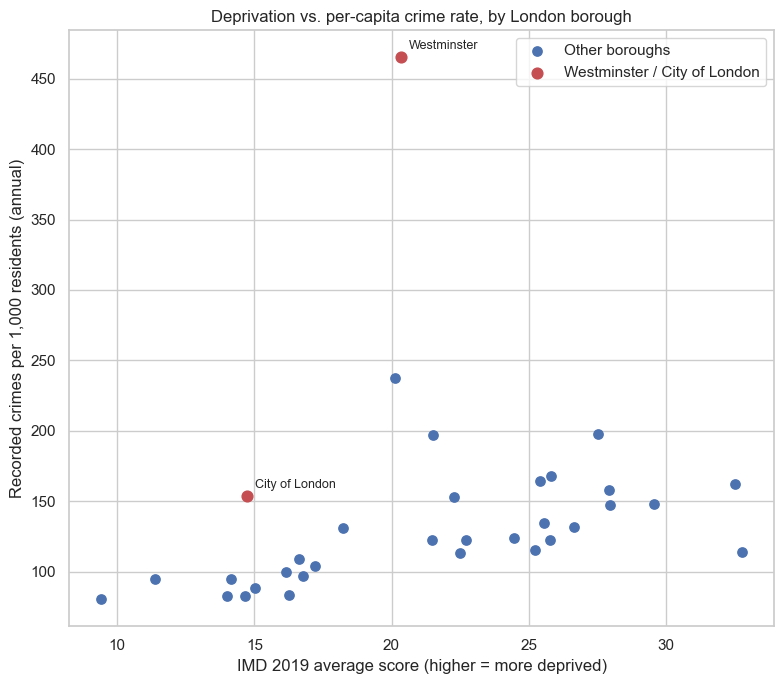

In [3]:
footfall_boroughs = ["Westminster", "City of London"]
is_footfall = merged["Borough"].isin(footfall_boroughs)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(
    merged.loc[~is_footfall, "IMD_score"], merged.loc[~is_footfall, "rate_per_1000"],
    color="#4C72B0", s=45, label="Other boroughs",
)
ax.scatter(
    merged.loc[is_footfall, "IMD_score"], merged.loc[is_footfall, "rate_per_1000"],
    color="#C44E52", s=60, label="Westminster / City of London",
)
for _, row in merged[is_footfall].iterrows():
    ax.annotate(
        row["Borough"], (row["IMD_score"], row["rate_per_1000"]),
        textcoords="offset points", xytext=(6, 6), fontsize=9,
    )

ax.set_xlabel("IMD 2019 average score (higher = more deprived)")
ax.set_ylabel("Recorded crimes per 1,000 residents (annual)")
ax.set_title("Deprivation vs. per-capita crime rate, by London borough")
ax.legend()
fig.tight_layout()

In [4]:
# .corr() computes the Pearson correlation coefficient between two Series:
# ranges from -1 (perfect inverse relationship) to +1 (perfect direct
# relationship), with 0 meaning no linear relationship at all.
excl = merged.loc[~is_footfall]

print(f"IMD_score    corr (all 33 boroughs):        {merged['rate_per_1000'].corr(merged['IMD_score']):.3f}")
print(f"IMD_score    corr (excl. Westminster/COL):  {excl['rate_per_1000'].corr(excl['IMD_score']):.3f}")
print(f"Income_score corr (all 33 boroughs):        {merged['rate_per_1000'].corr(merged['Income_score']):.3f}")
print(f"Income_score corr (excl. Westminster/COL):  {excl['rate_per_1000'].corr(excl['Income_score']):.3f}")

IMD_score    corr (all 33 boroughs):        0.263
IMD_score    corr (excl. Westminster/COL):  0.573
Income_score corr (all 33 boroughs):        0.272
Income_score corr (excl. Westminster/COL):  0.579


### Findings

- **Westminster is a stark vertical outlier** in the scatter plot: its
  deprivation score (~20) is only moderate — well below several other
  boroughs — yet its crime rate towers above any deprivation-based trend.
  This is more evidence for the footfall explanation from notebook 03,
  rather than deprivation.
- **Correlation across all 33 boroughs is weak (~0.26)** — but that's
  because Westminster and City of London distort it. **Excluding those two,
  it strengthens to ~0.57** — a moderate positive relationship: more
  deprived boroughs do tend to have higher per-capita crime rates, once the
  two footfall-driven boroughs are set aside.
- **The Income-only correlation (0.58) is almost identical to the overall
  IMD correlation (0.57).** Since Income contains no crime data at all,
  this is reassuring: the relationship isn't just IMD's own crime domain
  correlating with itself.
- **Caveat on causality:** this is a correlation across 31 boroughs at one
  point in time — nowhere near enough to claim deprivation *causes* crime.
  It's consistent with a real relationship, but so are several other
  explanations (e.g. both could be driven by a third factor like housing
  density or policing intensity).

## Where this leaves the project

We've now answered the original question reasonably well: crime *does*
vary meaningfully across London boroughs, population alone doesn't explain
it, and deprivation explains a moderate share of what's left — except for
two boroughs whose numbers are dominated by non-resident footfall rather
than resident risk. Natural directions from here (not started yet):

- A proper map (via `geopandas`/`folium`) instead of a bar chart, to see
  the spatial pattern directly.
- Bring in `west-mercia` data for a London vs. a smaller/rural force
  comparison.
- Look at crime *type* mix against deprivation, not just total volume
  (notebook 02's heatmap hinted some boroughs have distinctive profiles).